In [1]:
import starry
import starry_process
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding
theano.graph.opt.EquilibriumOptimizer
import numpy as np
import matplotlib.pyplot as plt

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [2]:
from starry_process.size import SizeIntegral
from starry_process.latitude import LatitudeIntegral
from starry_process.longitude import LongitudeIntegral
from starry_process.contrast import ContrastIntegral
from starry_process.ops import LatitudeIntegralOp
from starry_process.wigner import R
from starry_process.defaults import defaults
import numpy as np
from scipy.integrate import quad
from scipy.stats import beta as Beta
from tqdm import tqdm
from theano.configparser import change_flags
from starry_process.compat import theano, tt

In [3]:
from starry_process.defaults import defaults

log_alpha_max = defaults["log_alpha_max"]
log_beta_max  = defaults["log_beta_max"]

In [4]:
def alpha_beta_to_ab(alpha, beta,
                    log_alpha_max=10.0,
                    log_beta_max=10.0):

    alpha = np.asarray(alpha)
    beta  = np.asarray(beta)

    a = np.log(alpha) / log_alpha_max
    b = (np.log(beta) - np.log(0.5)) / (log_beta_max - np.log(0.5))

    return a, b

In [5]:
alpha = 5*np.sqrt(3)
beta = 10-alpha
lmax = 5

r = np.rad2deg(0.1)
c = 0.5
n = 1

a, b = alpha_beta_to_ab(alpha, beta)

In [7]:
sp = starry_process.StarryProcess(a=a,b=b,c=c,r=r,n=n,ydeg=lmax)

In [8]:
map = starry.Map(ydeg = lmax)
map.spot(radius=r, contrast=c)

Pre-computing some matrices... Done.


In [9]:
map.y.eval() 

array([ 1.        ,  0.        , -0.00428917,  0.        ,  0.        ,
        0.        , -0.00520534,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.00337815,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.00386738,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.00171843,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

In [37]:
er

array([ 0.99657637,  0.        , -0.00436468,  0.        ,  0.        ,
        0.        , -0.00531181,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.00344001,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.00395098,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.00175227,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

Compiling `render`... Done.


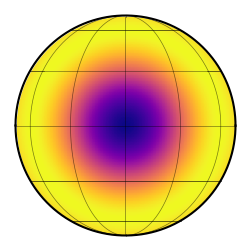

In [10]:
map.show()

In [11]:
er = np.array([
    0.99657637,
    0.0, -0.00436468, 0.0,
    0.0, 0.0, -0.00531181, 0.0, 0.0,
    0.0, 0.0, 0.0, -0.00344001, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, -0.00395098, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, -0.00175227, 0.0, 0.0, 0.0, 0.0, 0.0
])

In [12]:
N = (lmax + 1)**2
Er = np.zeros((N, N))

for l in range(lmax + 1):
    for lp in range(lmax + 1):
        Er[l**2 + l, lp**2 + lp] = er[l**2 + l] * er[lp**2 + lp]

In [13]:
class FixedER:
    def __init__(self, er, lmax):
        self.er = np.asarray(er, dtype=float)
        self.lmax = lmax
        self.N = (lmax + 1)**2

        self.eigEr = np.zeros((self.N, 1), dtype=float)

        for l in range(lmax + 1):
            i = l**2 + l  
            self.eigEr[i, 0] = self.er[i]

    def first_moment(self):
        return self.er

    def second_moment(self):
        return self.eigEr

In [14]:
S = FixedER(er, lmax)

I_lat = LatitudeIntegral(a, b, child=S, ydeg=lmax)

ephi = I_lat.first_moment().eval()

eigEphi = I_lat.second_moment().eval()
Ephi = eigEphi @ eigEphi.T

draw 1000 samples from SP, calculate the pixel variance and the ylm variance between the samples, 

In [52]:
sp.sample_ylm(nsamples=nsamples).eval()

array([[-0.10509577,  0.03314623,  0.02658103, ...,  0.01751334,
        -0.06407323, -0.00421399],
       [-0.10509742,  0.00473698, -0.05474322, ...,  0.07136456,
         0.04422093,  0.04174122],
       [-0.10509627, -0.00401794,  0.02738597, ...,  0.08786793,
        -0.0078695 , -0.03198048],
       ...,
       [-0.10509854, -0.02918601, -0.00773886, ...,  0.06733288,
        -0.05503204,  0.06721218],
       [-0.10509874, -0.00186791,  0.02360886, ...,  0.01799072,
         0.02014103,  0.06432701],
       [-0.10509709,  0.00224745,  0.0437913 , ...,  0.03294303,
         0.00647538, -0.072419  ]])

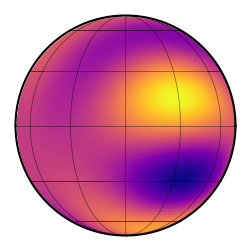

Compiling `RAxisAngle`... Done.
Compiling `pT`... Done.


In [59]:
nsamples = 1000

ys = sp.sample_ylm(nsamples=nsamples).eval()

ys = np.asarray(ys)

ylm_mean = np.mean(ys, axis=0)
ylm_var = np.var(ys, axis=0)

map[:,:] = ylm_var
map.show()

lat, lon, Y2P, P2Y, Dx, Dy = map.get_pixel_transforms(
    oversample=2,
    lam=1e-6,
    eps=1e-6
)

Y2P = np.asarray(Y2P)
p_samples = ys @ Y2P.T

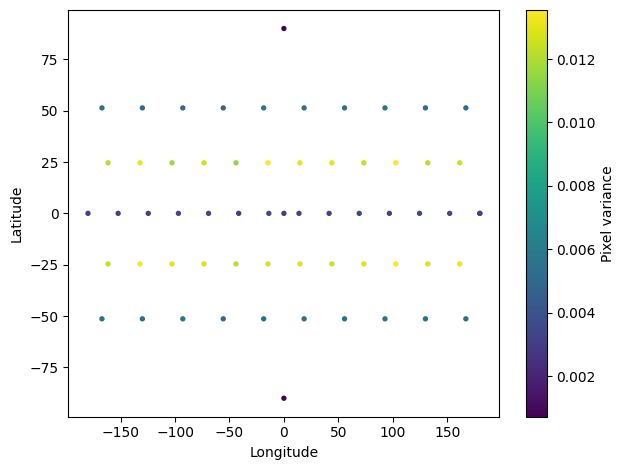

In [66]:
pix_mean = p_samples.mean(axis=0)
pix_var = p_samples.var(axis=0)

plt.scatter(lon, lat, c=pix_var, s=8)
plt.colorbar(label="Pixel variance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [15]:
ephi

array([ 9.96576370e-01,  0.00000000e+00, -3.77992376e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.40392283e-03,  0.00000000e+00,
        1.10151917e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.34178268e-03,  0.00000000e+00,  1.26828846e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -6.88361147e-04,  0.00000000e+00,  1.86043549e-03,  0.00000000e+00,
       -2.48092686e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -4.83530673e-05,  0.00000000e+00,
        8.63997019e-04,  0.00000000e+00, -2.44006693e-04,  0.00000000e+00])

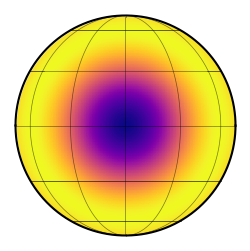

In [16]:
map[:,:] = er
map.show()

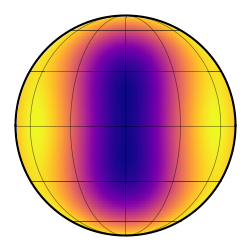

In [17]:
map[:,:] = ephi
map.show()

In [18]:
I_long = LongitudeIntegral(child=I_lat, ydeg=lmax)

In [19]:
elambda = I_long.first_moment().eval()

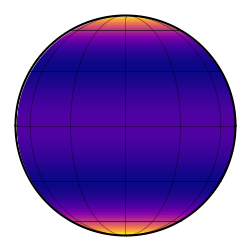

In [20]:
map[:,:] = elambda
map.show()

In [21]:
elambda

array([ 9.96576370e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.74008914e-04,  0.00000000e+00,
       -6.47802441e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.24404728e-04,  0.00000000e+00,  3.34522818e-04,  0.00000000e+00,
        4.42532092e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.60250277e-20,  0.00000000e+00,
       -2.73293957e-20,  0.00000000e+00,  6.83232695e-21,  0.00000000e+00])

In [22]:
np.log(Ephi.conj().T)

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_72673/2742142832.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(Ephi.conj().T)
/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_72673/2742142832.py:1: RuntimeWarning: invalid value encountered in log
  np.log(Ephi.conj().T)


array([[-6.85900806e-03,             nan,             nan, ...,
                   -inf,             nan,            -inf],
       [            nan, -1.22978221e+01,             nan, ...,
                   -inf, -4.51317196e+01,            -inf],
       [            nan,             nan, -1.11421372e+01, ...,
                   -inf, -1.40290925e+01,            -inf],
       ...,
       [           -inf,            -inf,            -inf, ...,
                   -inf,            -inf,            -inf],
       [            nan, -4.51317196e+01, -1.40290925e+01, ...,
                   -inf, -1.58845749e+01,            -inf],
       [           -inf,            -inf,            -inf, ...,
                   -inf,            -inf,            -inf]])

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_72673/1566870390.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(Ephi.conj().T))
/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_72673/1566870390.py:1: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(Ephi.conj().T))


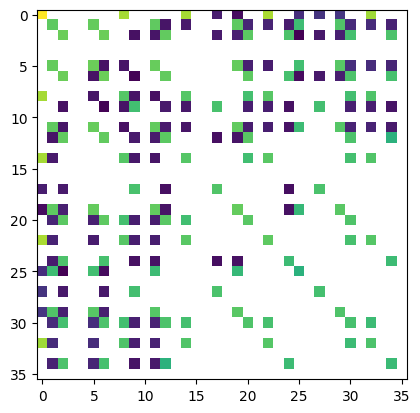

In [23]:
plt.imshow(np.log(Ephi.conj().T))

In [24]:
Ephi

array([[ 9.93164461e-01, -2.70617036e-19, -3.76698270e-03, ...,
         0.00000000e+00, -2.43171304e-04,  0.00000000e+00],
       [-2.70617036e-19,  4.56166842e-06, -8.34159675e-21, ...,
         0.00000000e+00,  2.50924586e-20,  0.00000000e+00],
       [-3.76698270e-03, -8.34159675e-21,  1.44887631e-05, ...,
         0.00000000e+00,  8.07685973e-07,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.43171304e-04,  2.50924586e-20,  8.07685973e-07, ...,
         0.00000000e+00,  1.26303909e-07,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

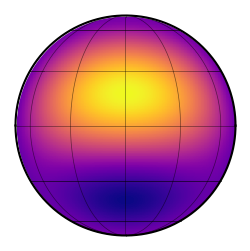

In [25]:
map[:,:] = np.diag(Ephi)
map.show()

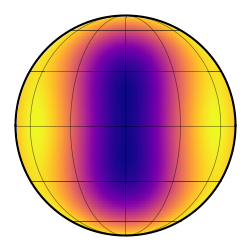

In [26]:
map[:,:] = Ephi[:,0]
map.show()

In [27]:
Ephi

array([[ 9.93164461e-01, -2.70617036e-19, -3.76698270e-03, ...,
         0.00000000e+00, -2.43171304e-04,  0.00000000e+00],
       [-2.70617036e-19,  4.56166842e-06, -8.34159675e-21, ...,
         0.00000000e+00,  2.50924586e-20,  0.00000000e+00],
       [-3.76698270e-03, -8.34159675e-21,  1.44887631e-05, ...,
         0.00000000e+00,  8.07685973e-07,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.43171304e-04,  2.50924586e-20,  8.07685973e-07, ...,
         0.00000000e+00,  1.26303909e-07,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [28]:
I_lon = LongitudeIntegral(child=I_lat, ydeg=lmax)

elambda = I_lon.first_moment().eval()

eigElambda = I_lon.second_moment().eval()
Elambda = eigElambda @ eigElambda.T

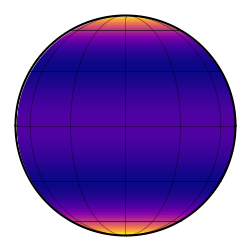

In [29]:
map[:,:] = elambda
map.show()

In [30]:
elambda

array([ 9.96576370e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.74008914e-04,  0.00000000e+00,
       -6.47802441e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.24404728e-04,  0.00000000e+00,  3.34522818e-04,  0.00000000e+00,
        4.42532092e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.60250277e-20,  0.00000000e+00,
       -2.73293957e-20,  0.00000000e+00,  6.83232695e-21,  0.00000000e+00])

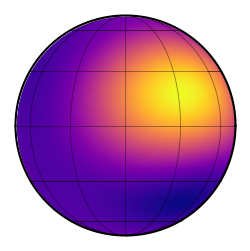

In [31]:
map[:,:] = np.diag(Elambda)
map.show()

In [32]:
Elambda

array([[ 9.93164461e-01, -2.15387047e-19,  6.71694166e-19, ...,
         2.63695507e-20,  4.59187787e-19,  1.05120971e-20],
       [-2.15387047e-19,  4.56166842e-06, -1.90164089e-21, ...,
        -1.01476543e-21, -1.45467098e-22, -3.57342503e-21],
       [ 6.71694166e-19, -1.90164089e-21,  7.24438154e-06, ...,
         6.33993194e-20, -4.27780804e-07,  1.09890481e-20],
       ...,
       [ 2.63695507e-20, -1.01476543e-21,  6.33993194e-20, ...,
         2.58341447e-07,  3.49235306e-20, -2.19461423e-08],
       [ 4.59187787e-19, -1.45467098e-22, -4.27780804e-07, ...,
         3.49235306e-20,  2.47653452e-07,  2.79307668e-21],
       [ 1.05120971e-20, -3.57342503e-21,  1.09890481e-20, ...,
        -2.19461423e-08,  2.79307668e-21,  2.18209612e-07]])

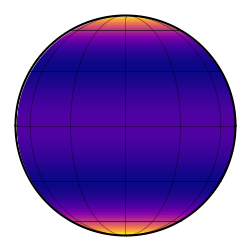

In [33]:
map[:,:] = Elambda[:,0]
map.show()

In [34]:
variance_matrix = Elambda - elambda[:, None] * elambda[None, :]

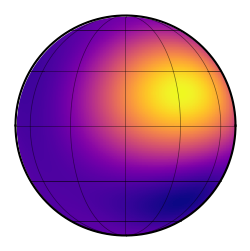

In [35]:
map[:,:] = np.diag(variance_matrix)
map.show()

In [36]:
np.diag(variance_matrix)

array([-3.33066907e-16,  4.56166842e-06,  7.24438154e-06,  7.24438154e-06,
        6.54063749e-06,  6.54063749e-06,  5.24663099e-06,  6.41200414e-06,
        2.91588470e-06,  1.88912327e-06,  2.37277999e-06,  2.08258596e-06,
        1.49061184e-06,  1.78640419e-06,  1.25397795e-06,  9.58185601e-07,
        1.60230852e-06,  2.12994025e-06,  2.50682005e-06,  1.97918833e-06,
        1.50755169e-06,  1.73651282e-06,  1.37126549e-06,  1.36737091e-06,
        1.05118726e-06,  2.32595369e-07,  2.88327353e-07,  3.61577426e-07,
        3.92539639e-07,  2.99006987e-07,  2.56381024e-07,  2.71650630e-07,
        2.44167214e-07,  2.58341447e-07,  2.47653452e-07,  2.18209612e-07])

Pre-computing some matrices... Done.
Compiling `RAxisAngle`... Done.
Compiling `pT`... Done.


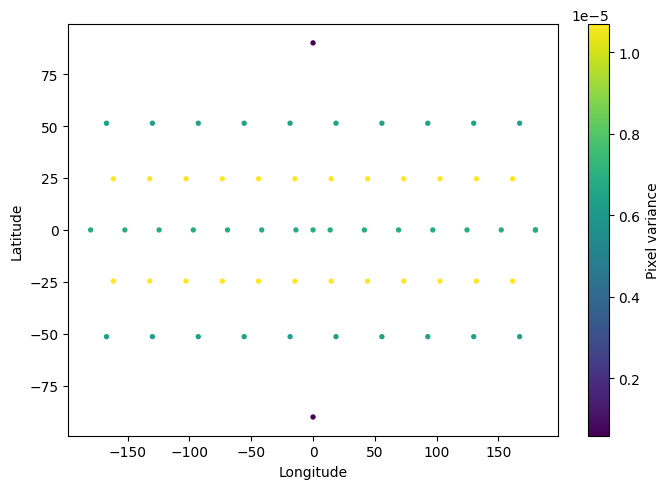

In [68]:
m = starry.Map(ydeg=lmax)

lat, lon, Y2P, P2Y, Dx, Dy = m.get_pixel_transforms(
    oversample=2,
    lam=1e-6,
    eps=1e-6
)

Y2P = np.asarray(Y2P)

pix_mean = Y2P @ elambda

Epix = Y2P @ Elambda @ Y2P.T

pix_var = np.diag(Epix) - pix_mean**2

plt.figure(figsize=(7, 5))
plt.scatter(lon, lat, c=pix_var, s=8)
plt.colorbar(label="Pixel variance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [37]:
sp.cov_ylm.eval()

array([[ 9.99999955e-13,  3.11303192e-20, -3.89618859e-20, ...,
        -8.65095399e-21, -1.48414025e-19, -3.44845063e-21],
       [ 3.11303192e-20,  5.88088608e-05,  3.09210793e-20, ...,
         2.65682415e-21, -4.95474114e-21,  6.05231882e-22],
       [-3.89618859e-20,  3.09210793e-20,  9.33942987e-05, ...,
        -1.36019740e-20, -4.77825556e-05,  8.52991788e-20],
       ...,
       [-8.65095399e-21,  2.65682415e-21, -1.36019740e-20, ...,
         2.50017959e-04, -1.40904667e-19, -2.12390607e-05],
       [-1.48414025e-19, -4.95474114e-21, -4.77825556e-05, ...,
        -1.40904667e-19,  2.39674320e-04,  1.63848639e-19],
       [-3.44845063e-21,  6.05231882e-22,  8.52991788e-20, ...,
        -2.12390607e-05,  1.63848639e-19,  2.11179130e-04]])

In [38]:
sp.mean_ylm.eval()

array([-1.05097770e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.82354133e-03,  0.00000000e+00,
       -3.15846623e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.22018536e-03,  0.00000000e+00,  4.80036892e-03,  0.00000000e+00,
        6.35029118e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -4.98525465e-19,  0.00000000e+00,
       -8.50195080e-19,  0.00000000e+00,  2.12548086e-19,  0.00000000e+00])

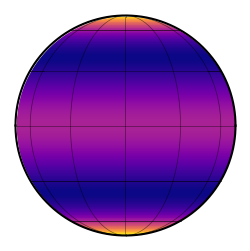

In [39]:
map[:,:] = sp.mean_ylm.eval()
map.show()

In [40]:
# alpha = 5*np.sqrt(3)
# beta = 10-alpha
# lmax = 5

# r = np.rad2deg(0.1)
# c = 0.5

# a, b = alpha_beta_to_ab(alpha, beta)

# sp = StarryProcess(a=a, b=b, r=r, c=c, n=1, ydeg=lmax)

mean = sp.mean_ylm.eval()
cov  = sp.cov_ylm.eval()

In [41]:
mean

array([-1.05097770e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.82354133e-03,  0.00000000e+00,
       -3.15846623e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.22018536e-03,  0.00000000e+00,  4.80036892e-03,  0.00000000e+00,
        6.35029118e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -4.98525465e-19,  0.00000000e+00,
       -8.50195080e-19,  0.00000000e+00,  2.12548086e-19,  0.00000000e+00])

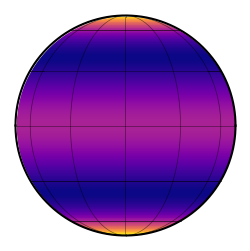

In [42]:
map[:,:] = mean
map.show()

In [43]:
cov

array([[ 9.99999955e-13,  3.11303192e-20, -3.89618859e-20, ...,
        -8.65095399e-21, -1.48414025e-19, -3.44845063e-21],
       [ 3.11303192e-20,  5.88088608e-05,  3.09210793e-20, ...,
         2.65682415e-21, -4.95474114e-21,  6.05231882e-22],
       [-3.89618859e-20,  3.09210793e-20,  9.33942987e-05, ...,
        -1.36019740e-20, -4.77825556e-05,  8.52991788e-20],
       ...,
       [-8.65095399e-21,  2.65682415e-21, -1.36019740e-20, ...,
         2.50017959e-04, -1.40904667e-19, -2.12390607e-05],
       [-1.48414025e-19, -4.95474114e-21, -4.77825556e-05, ...,
        -1.40904667e-19,  2.39674320e-04,  1.63848639e-19],
       [-3.44845063e-21,  6.05231882e-22,  8.52991788e-20, ...,
        -2.12390607e-05,  1.63848639e-19,  2.11179130e-04]])

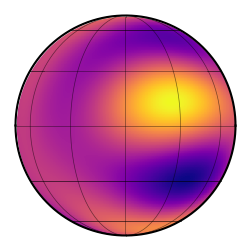

In [44]:
map[:,:] = np.diag(cov)
map.show()

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_72673/282266317.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(cov))


Text(0.5, 1.0, 'starry process')

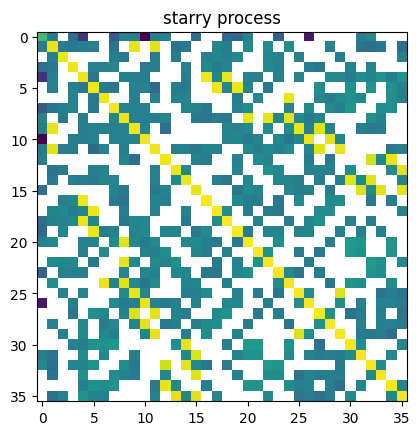

In [45]:
plt.imshow(np.log10(cov))
plt.title('starry process')

In [46]:
np.log10(cov)

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_72673/2270484336.py:1: RuntimeWarning: invalid value encountered in log10
  np.log10(cov)


array([[-12.00000002, -19.50681643,          nan, ...,          nan,
                 nan,          nan],
       [-19.50681643,  -4.23055723, -19.50974536, ..., -20.57563719,
                 nan, -21.2180782 ],
       [         nan, -19.50974536,  -4.02967963, ...,          nan,
                 nan, -19.06905515],
       ...,
       [         nan, -20.57563719,          nan, ...,  -3.60202879,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
         -3.6203785 , -18.78555716],
       [         nan, -21.2180782 , -19.06905515, ...,          nan,
        -18.78555716,  -3.675349  ]])

In [57]:
mean_c = ContrastIntegral(child=I_lon, ydeg=lmax, c=c, n=n).mean().eval()

In [63]:
cov_c = ContrastIntegral(child=I_lon, ydeg=lmax, c=c, n=n)._cov.eval()

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_72673/3188744963.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(cov_c))


Text(0.5, 1.0, 'starry process')

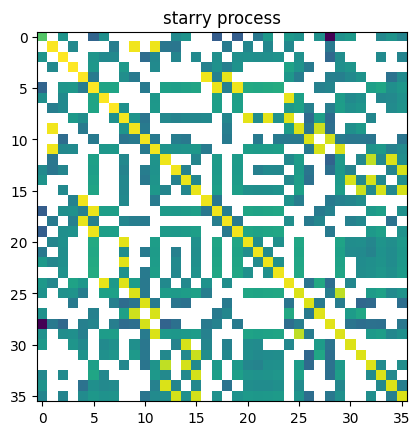

In [64]:
plt.imshow(np.log10(cov_c))
plt.title('starry process')

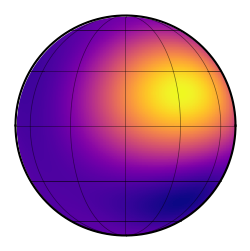

In [65]:
map[:,:] = np.diag(cov_c)
map.show()

In [66]:
cov_c

array([[ 9.99308780e-13, -5.31446238e-19,  1.65733892e-18, ...,
         6.50642583e-20,  1.11620008e-18,  2.59375599e-20],
       [-5.31446238e-19,  1.12554667e-05, -4.69211082e-21, ...,
        -2.50383335e-21, -3.58925677e-22, -8.81707285e-21],
       [ 1.65733892e-18, -4.69211082e-21,  1.78747960e-05, ...,
         1.56431550e-19, -1.05550683e-06,  2.71143893e-20],
       ...,
       [ 6.50642583e-20, -2.50383335e-21,  1.56431550e-19, ...,
         6.37432971e-07,  8.61703577e-20, -5.41499357e-08],
       [ 1.11620008e-18, -3.58925677e-22, -1.05550683e-06, ...,
         8.61703577e-20,  6.11061400e-07,  6.89164048e-21],
       [ 2.59375599e-20, -8.81707285e-21,  2.71143893e-20, ...,
        -5.41499357e-08,  6.89164048e-21,  5.38411638e-07]])

In [68]:
np.save('sp_cov_c.npy', cov_c)

In [69]:
np.save('sp_mean_c.npy', mean_c)

In [70]:
mean_c

array([ 1.56541850e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -5.87491828e-04,  0.00000000e+00,
       -1.01756569e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.52494123e-04,  0.00000000e+00,  5.25467214e-04,  0.00000000e+00,
        6.95127785e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -2.51720547e-20,  0.00000000e+00,
       -4.29289144e-20,  0.00000000e+00,  1.07321941e-20,  0.00000000e+00])